# 키스킷 신경망의 유효 차원(Effective Dimension of Qiskit Neural Networks)
이 튜토리얼에서는 `EffectiveDimension` 및 `LocalEffectiveDimension` 클래스를 활용하여 양자 신경망(Quantum Neural Network) 모델의 성능을 평가한다. 이는 정보 기하학(information geometry) 기반의 메트릭으로 훈련 가능성(trainability), 표현력(expressibility), 일반화 능력(ability to generalize)과 같은 개념과 연결된다.

코드 예제를 살펴보기 전에 이 두 메트릭의 차이점과 양자 신경망 연구에 대한 관련성을 간단히 설명한다. 전역 유효 차원(global effective dimension)에 대한 자세한 정보는 [이 논문](https://arxiv.org/pdf/2011.00027.pdf)에서 찾을 수 있으며, 지역 유효 차원(local effective dimension)은 [나중의 연구](https://arxiv.org/abs/2112.04807)에서 소개되었다.

## 1. 전역 유효 차원 vs. 지역 유효 차원(Global vs. Local Effective Dimension)
고전 머신러닝과 양자 머신러닝 모델은 공통의 목표를 공유한다: **일반화**에 잘하기, 즉 데이터에서 통찰력을 학습하고 이를 보지 못한 데이터에 적용하기.

이 능력을 평가할 좋은 메트릭을 찾는 것은 자명하지 않은 문제다. [양자 신경망의 힘(The Power of Quantum Neural Networks)](https://arxiv.org/pdf/2011.00027.pdf)에서 저자들은 **전역** 유효 차원을 특정 모델이 새로운 데이터에 얼마나 잘 수행할 수 있는지를 나타내는 유용한 지표로 소개한다. [머신러닝 모델의 유효 차원(Effective Dimension of Machine Learning Models)](https://arxiv.org/pdf/2112.04807.pdf)에서 **지역** 유효 차원은 머신러닝 모델의 일반화 오류를 제한하는 새로운 용량 측정으로 제안된다.

전역(`EffectiveDimension` 클래스)과 **지역** 유효 차원(`LocalEffectiveDimension` 클래스)의 핵심 차이점은 실제로 계산 방식이 아니라 분석되는 매개변수 공간의 성질에 있다. 전역 유효 차원은 모델의 **전체 매개변수 공간**을 포함하며, **다수의 매개변수(가중치) 집합**에서 계산된다. 반면 지역 유효 차원은 **훈련된** 모델이 새로운 데이터에 얼마나 잘 일반화될 수 있는지, 그리고 **표현력**이 있는지에 초점을 맞춘다. 따라서 지역 유효 차원은 **단일** 가중치 샘플 집합(훈련 결과)에서 계산된다. 이 차이는 실제 구현 측면에서는 작지만 개념적 수준에서는 매우 관련이 있다.

## 2. 유효 차원 알고리즘(The Effective Dimension Algorithm)

전역 및 지역 유효 차원 알고리즘 모두 복잡성의 측도를 제공하기 위해 피셔 정보 행렬(Fisher Information matrix)을 사용한다. 이 행렬이 어떻게 계산되는지에 대한 세부 사항은 [참고 논문](https://arxiv.org/pdf/2011.00027.pdf)에서 제공되지만, 일반적으로 이 행렬은 신경망의 출력이 네트워크의 매개변수 공간 변화에 얼마나 민감한지를 캡처한다.

특히, 이 알고리즘은 4가지 주요 단계를 따른다:

1. **몬테카를로 시뮬레이션(Monte Carlo simulation):** 입력 및 가중치 샘플의 각 쌍에 대해 신경망의 순전파(forward pass)와 역전파(backpass) (기울기(gradients))가 계산된다.
2. **피셔 행렬 계산(Fisher Matrix Computation):** 이러한 출력과 기울기를 사용하여 피셔 정보 행렬이 계산된다.
3. **피셔 행렬 정규화(Fisher Matrix Normalization):** 모든 입력 샘플에 대해 평균화하고 행렬 대각합(trace)으로 나누기
4. **유효 차원 계산(Effective Dimension Calculation):** [*Abbas et al.*](https://arxiv.org/pdf/2011.00027.pdf)의 공식에 따라

## 3. 기본 예제(Basic Example (SamplerQNN))

이 예제는 QNN 모델 문제를 설정하고 전역 유효 차원 알고리즘을 실행하는 방법을 보여준다. 키스킷의 `SamplerQNN` (이 예제에서 보여주는)과 `EstimatorQNN` (나중 예제에서 보여주는) 모두 `EffectiveDimension` 클래스와 함께 사용할 수 있다.

필요한 임포트와 재현성을 위한 난수 생성기의 고정된 시드로 시작한다.

In [1]:
# 필수 라이브러리들을 임포트한다(Import necessary libraries)
# Necessary imports
import matplotlib.pyplot as plt
import numpy as np
from IPython.display import clear_output
from qiskit import QuantumCircuit
from qiskit.circuit.library import z_feature_map, real_amplitudes
from qiskit_machine_learning.optimizers import COBYLA
from qiskit_machine_learning.utils import algorithm_globals
from qiskit.primitives import StatevectorSampler as Sampler, StatevectorEstimator as Estimator

from sklearn.datasets import make_classification
from sklearn.preprocessing import MinMaxScaler

from qiskit_machine_learning.circuit.library import qnn_circuit
from qiskit_machine_learning.algorithms.classifiers import NeuralNetworkClassifier
from qiskit_machine_learning.neural_networks import EffectiveDimension, LocalEffectiveDimension
from qiskit_machine_learning.neural_networks import SamplerQNN, EstimatorQNN

# set random seed
algorithm_globals.random_seed = 42
sampler = Sampler()
estimator = Estimator()

### 3.1 QNN 정의(Define QNN)

`SamplerQNN`을 만들기 위한 첫 번째 단계는 매개변수화된 특징 맵(feature map)과 ansatz를 정의하는 것이다. 이 장난감 예제에서는 3개의 큐비트를 사용하고 `qnn_circuit` 함수를 사용하여 특징 맵과 ansatz 회로의 조합을 단순화한다. 결과 회로는 그 다음 `SamplerQNN` 클래스에서 사용된다.

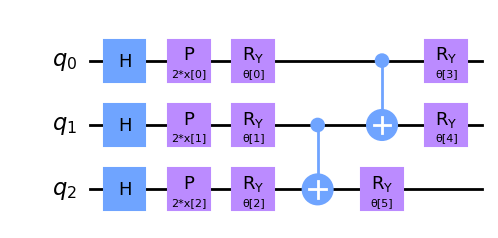

In [2]:
# 특징 맵과 ansatz를 결합하여 QNN 회로를 생성한다(Create QNN circuit by combining feature map and ansatz)
num_qubits = 3
# combine a custom feature map and ansatz into a single circuit
qc, fm_params, anz_params = qnn_circuit(
    feature_map=z_feature_map(feature_dimension=num_qubits, reps=1),
    ansatz=real_amplitudes(num_qubits, reps=1),
)
qc.draw(output="mpl", style="clifford")

매개변수화된 회로는 선택적 해석 맵(interpret map) (이 경우 패리티(parity))과 함께 `SamplerQNN` 생성자로 전송될 수 있다.

In [3]:
# 패리티 함수와 출력 형태를 정의한다(Define parity function and output shape)
# parity maps bitstrings to 0 or 1
def parity(x):
    return "{:b}".format(x).count("1") % 2


output_shape = 2  # corresponds to the number of classes, possible outcomes of the (parity) mapping.

In [4]:
# SamplerQNN을 생성한다(Construct SamplerQNN)
# construct QNN
qnn = SamplerQNN(
    circuit=qc,
    input_params=fm_params,
    weight_params=anz_params,
    interpret=parity,
    output_shape=output_shape,
    sparse=False,
    sampler=sampler,
)

No gradient function provided, creating a gradient function. If your Sampler requires transpilation, please provide a pass manager.


`EffectiveDimension` 클래스를 사용하여 QNN의 유효 차원을 계산하기 위해서는 입력 샘플과 가중치의 여러 집합, 그리고 데이터셋에서 사용 가능한 총 데이터 샘플 수가 필요하다. `input_samples`과 `weight_samples`은 클래스 생성자에서 설정되며, 데이터 샘플의 수는 유효 차원 계산 호출 중에 주어진다. 이렇게 하면 이 측도가 다양한 데이터셋 크기에 따라 어떻게 변하는지 테스트하고 비교할 수 있다.

`input_samples`과 `weight_samples`의 샘플 수를 정의할 수 있으며, 클래스는 정규 분포(normal distribution)(`input_samples`의 경우) 또는 균등 분포(uniform distribution)(`weight_samples`의 경우)에서 해당 배열을 무작위로 샘플링한다. 샘플 수를 전달하는 대신 수동으로 샘플된 배열을 전달할 수 있다.

In [5]:
# 입력 샘플과 가중치 샘플의 수를 설정하고 전역 유효 차원 인스턴스를 생성한다(Set number of samples and create global effective dimension instance)
# we can set the total number of input samples and weight samples for random selection
num_input_samples = 10
num_weight_samples = 10

global_ed = EffectiveDimension(
    qnn=qnn, weight_samples=num_weight_samples, input_samples=num_input_samples
)

특정 입력 샘플 및 가중치 샘플 집합을 테스트하려면 다음 스니펫에 표시된 대로 이를 `EffectiveDimension` 클래스에 직접 제공할 수 있다:

In [6]:
# 사용자 정의 샘플과 매개변수를 제공한다(Provide user-defined samples and parameters)
# we can also provide user-defined samples and parameters
input_samples = algorithm_globals.random.normal(0, 1, size=(10, qnn.num_inputs))
weight_samples = algorithm_globals.random.uniform(0, 1, size=(10, qnn.num_weights))

global_ed = EffectiveDimension(qnn=qnn, weight_samples=weight_samples, input_samples=input_samples)

유효 차원 알고리즘은 또한 데이터셋 크기를 필요로 한다. 이 예제에서는 나중에 이 입력이 결과에 어떤 영향을 미치는지 보기 위해 크기의 배열을 정의한다.

In [7]:
# 테스트할 데이터 크기의 범위를 정의한다(Define ranges of data sizes to test)
# finally, we will define ranges to test different numbers of data, n
n = [5000, 8000, 10000, 40000, 60000, 100000, 150000, 200000, 500000, 1000000]

이제 이전에 정의된 입력 샘플, 가중치 및 데이터셋 크기 5000에 대해 네트워크의 유효 차원을 계산해 보자.

In [8]:
# 정의된 입력 샘플, 가중치, 데이터셋 크기 5000에 대해 유효 차원을 계산한다(Compute effective dimension for defined inputs)
global_eff_dim_0 = global_ed.get_effective_dimension(dataset_size=n[0])

유효 차원 값은 0과 `d` 사이의 범위에 있으며, 여기서 `d`는 모델의 차원을 나타내고 실제로는 QNN의 가중치 수에서 얻어진다. 결과를 `d`로 나누면 정규화된 유효 차원(normalized effective dimension)을 얻을 수 있으며, 이는 모델의 용량과 직접 관련된다.

In [9]:
# 가중치 수와 정규화된 유효 차원을 출력한다(Print weight count and normalized effective dimension)
d = qnn.num_weights

print("Data size: {}, global effective dimension: {:.4f}".format(n[0], global_eff_dim_0))
print(
    "Number of weights: {}, normalized effective dimension: {:.4f}".format(d, global_eff_dim_0 / d)
)

Data size: 5000, global effective dimension: 4.6797
Number of weights: 6, normalized effective dimension: 0.7799


`EffectiveDimension` 클래스를 입력 크기 `n`의 배열로 호출하면 유효 차원이 데이터셋 크기에 따라 어떻게 변하는지 모니터링할 수 있다.

In [10]:
# 다양한 데이터셋 크기에 대해 유효 차원을 계산한다(Compute effective dimension for various dataset sizes)
global_eff_dim_1 = global_ed.get_effective_dimension(dataset_size=n)

In [11]:
# 유효 차원과 가중치 수를 출력한다(Print effective dimension and weight count)
print("Effective dimension: {}".format(global_eff_dim_1))
print("Number of weights: {}".format(d))

Effective dimension: [4.68941521 4.74131953 4.76760058 4.93721647 4.98490668 5.04190563
 5.08433158 5.11284393 5.1949652  5.24890058]
Number of weights: 6


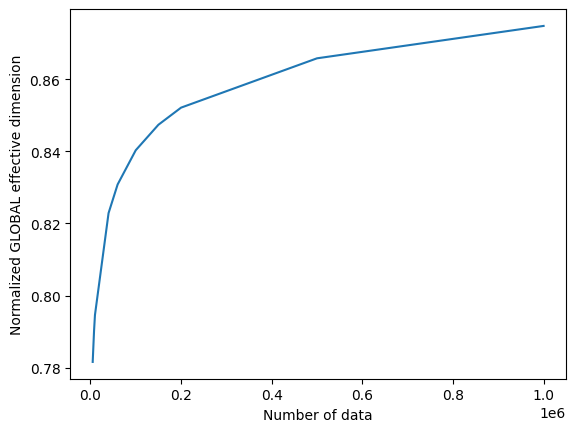

In [12]:
# 모델의 정규화된 전역 유효 차원을 플롯한다(Plot normalized global effective dimension for the model)
# plot the normalized effective dimension for the model
plt.plot(n, np.array(global_eff_dim_1) / d)
plt.xlabel("Number of data")
plt.ylabel("Normalized GLOBAL effective dimension")
plt.show()

소개에서 설명했듯이 지역 유효 차원 알고리즘은 **단 하나의** 가중치 집합만 사용하며, 이를 사용하여 훈련이 신경망의 표현력에 어떤 영향을 미치는지 모니터링할 수 있다. `LocalEffectiveDimension` 클래스는 이 제약 조건을 적용하여 이러한 계산이 개념적으로 분리되도록 하지만, 나머지 구현은 `EffectiveDimension`과 공유된다.

이 예제는 `LocalEffectiveDimension` 클래스를 활용하여 QNN 표현력에 대한 훈련의 영향을 분석하는 방법을 보여준다.

### 4.1 데이터셋 및 QNN 정의(Define Dataset and QNN)

scikit-learn의 `make_classification` 함수를 사용하여 3차원 이진 분류 데이터셋을 생성하여 시작한다.

In [13]:
# 이진 분류 데이터셋을 생성하고 전처리한다(Generate and preprocess binary classification dataset)
num_inputs = 3
num_samples = 50

X, y = make_classification(
    n_samples=num_samples,
    n_features=num_inputs,
    n_informative=3,
    n_redundant=0,
    n_clusters_per_class=1,
    class_sep=2.0,
)
X = MinMaxScaler().fit_transform(X)
y = 2 * y - 1  # labels in {-1, 1}

다음 단계는 QNN을 생성하는 것이다. 이 경우 `SamplerQNN`의 인스턴스를 생성한 것과 같은 방식으로 `EstimatorQNN`의 인스턴스를 생성한다.

In [14]:
# EstimatorQNN의 인스턴스를 생성한다(Create EstimatorQNN instance)
estimator_qnn = EstimatorQNN(
    circuit=qc, input_params=fm_params, weight_params=anz_params, estimator=estimator
)

No gradient function provided, creating a gradient function. If your Estimator requires transpilation, please provide a pass manager.


이제 QNN을 훈련할 수 있다. 훈련 단계는 시간이 걸릴 수 있으니 참고 바란다. 훈련 과정이 어떻게 진행되는지 보기 위해 콜백(callback)을 분류기에 전달할 수 있다. 일반적으로 재현성을 위해 `initial_point`를 고정한다.

In [15]:
# .fit() 메서드가 호출될 때 라이브 플롯을 그리는 콜백 함수를 정의한다(Define callback function that draws live plot when .fit() is called)
# callback function that draws a live plot when the .fit() method is called
def callback_graph(weights, obj_func_eval):
    clear_output(wait=True)
    objective_func_vals.append(obj_func_eval)
    plt.title("Objective function value against iteration")
    plt.xlabel("Iteration")
    plt.ylabel("Objective function value")
    plt.plot(range(len(objective_func_vals)), objective_func_vals)
    plt.show()

In [16]:
# 분류기를 구성한다(Construct classifier)
# construct classifier
initial_point = algorithm_globals.random.random(estimator_qnn.num_weights)

estimator_classifier = NeuralNetworkClassifier(
    neural_network=estimator_qnn,
    optimizer=COBYLA(maxiter=80),
    initial_point=initial_point,
    callback=callback_graph,
)

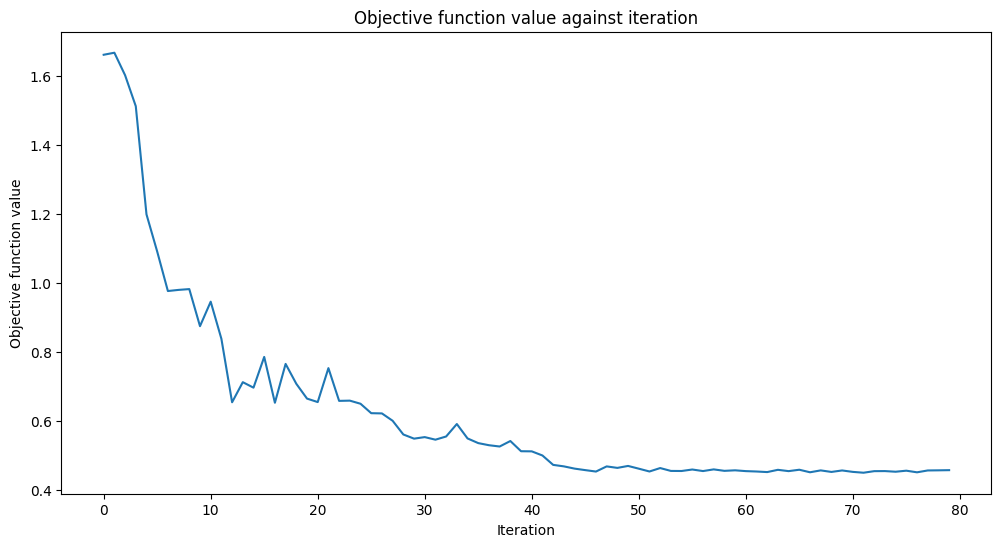

In [17]:
# 데이터에 분류기를 맞춘다(Fit classifier to data)
# create empty array for callback to store evaluations of the objective function (callback)
objective_func_vals = []
plt.rcParams["figure.figsize"] = (12, 6)

# fit classifier to data
estimator_classifier.fit(X, y)

# return to default figsize
plt.rcParams["figure.figsize"] = (6, 4)

분류기는 이제 다음의 정확도로 클래스를 구분할 수 있다:

In [18]:
# 분류기의 점수를 계산한다(Score classifier)
# score classifier
estimator_classifier.score(X, y)

0.98

### 4.3 훈련된 QNN의 지역 유효 차원 계산(Compute Local Effective Dimension of trained QNN)

이제 네트워크를 훈련했으므로, 훈련된 가중치를 기반으로 지역 유효 차원을 평가해 보자. 이를 위해 분류기에서 훈련된 가중치에 직접 접근한다.

In [19]:
# 훈련된 가중치에 대한 지역 유효 차원을 계산한다(Get local effective dimension for trained weights)
trained_weights = estimator_classifier.weights

# get Local Effective Dimension for set of trained weights
local_ed_trained = LocalEffectiveDimension(
    qnn=estimator_qnn, weight_samples=trained_weights, input_samples=X
)

local_eff_dim_trained = local_ed_trained.get_effective_dimension(dataset_size=n)

print(
    "normalized local effective dimensions for trained QNN: ",
    local_eff_dim_trained / estimator_qnn.num_weights,
)

normalized local effective dimensions for trained QNN:  [0.49311836 0.50460783 0.51054274 0.55270166 0.56624091 0.5836957
 0.59769038 0.60760798 0.63849805 0.66050704]


### 4.4 훈련되지 않은 QNN의 지역 유효 차원 계산(Compute Local Effective Dimension of untrained QNN)

이 결과를 훈련되지 않은 네트워크의 유효 차원과 비교할 수 있으며, `initial_point`를 가중치 샘플로 사용한다:

In [20]:
# 훈련되지 않은 가중치에 대한 지역 유효 차원을 계산한다(Get local effective dimension for untrained weights)
# get Local Effective Dimension for set of untrained weights
local_ed_untrained = LocalEffectiveDimension(
    qnn=estimator_qnn, weight_samples=initial_point, input_samples=X
)

local_eff_dim_untrained = local_ed_untrained.get_effective_dimension(dataset_size=n)

print(
    "normalized local effective dimensions for untrained QNN: ",
    local_eff_dim_untrained / estimator_qnn.num_weights,
)

normalized local effective dimensions for untrained QNN:  [0.69202357 0.70522065 0.71185271 0.7537262  0.76519992 0.77876226
 0.78876592 0.7954522  0.81458271 0.82707371]


### 4.5 결과 플롯 및 분석(Plot and analyze results)

훈련 전후의 유효 차원 값을 플롯하면 다음의 결과를 볼 수 있다:

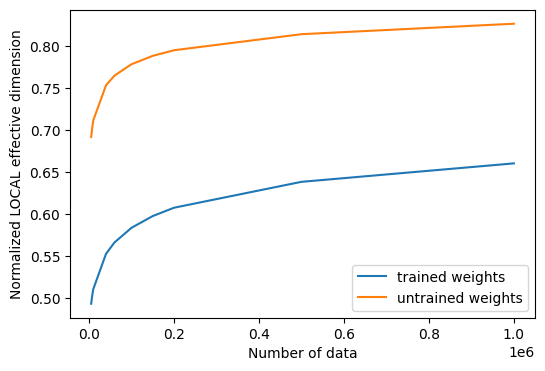

In [21]:
# 모델의 정규화된 지역 유효 차원을 플롯한다(Plot normalized local effective dimension for the model)
# plot the normalized effective dimension for the model
plt.plot(n, np.array(local_eff_dim_trained) / estimator_qnn.num_weights, label="trained weights")
plt.plot(
    n, np.array(local_eff_dim_untrained) / estimator_qnn.num_weights, label="untrained weights"
)

plt.xlabel("Number of data")
plt.ylabel("Normalized LOCAL effective dimension")
plt.legend()
plt.show()

일반적으로 지역 유효 차원의 값이 훈련 후 감소할 것으로 예상해야 한다. 이는 머신러닝의 주요 목표를 다시 살펴봄으로써 이해할 수 있다. 즉, 데이터에 맞출 수 있을 만큼 표현력 있는 모델을 선택하되, 과적합(overfit)되어 새로운 데이터 샘플에서 성능이 나쁜 모델은 피하는 것이다.

특정 최적화 알고리즘은 매개변수를 학습함으로써 모델의 과적합을 정규화하는 데 도움이 되며, 이러한 학습 행동은 지역 유효 차원으로 측정되는 모델의 표현력을 내재적으로 감소시킨다. 이 논리에 따르면, 무작위로 초기화된 매개변수 집합은 최종 훈련된 가중치 집합보다 더 높은 유효 차원을 생성할 가능성이 높다. 왜냐하면 그 특정 매개변수화를 가진 모델은 데이터에 맞추기 위해 불필요하게 "더 많은 매개변수를 사용"하고 있기 때문이다. 훈련 후 (암시적 정규화 포함), 훈련된 모델은 많은 매개변수를 사용할 필요가 없으므로 더 많은 "비활성 매개변수"를 가지며 지역 유효 차원이 낮아진다.

그러나 우리는 이것이 일반적인 직관이며, 무작위로 선택된 가중치 집합이 특정 모델에 대해 훈련된 가중치보다 낮은 유효 차원을 제공하는 경우가 있을 수 있다는 점을 명심해야 한다.

In [22]:
# 버전 정보 및 저작권을 표시한다(Display version information and copyright)
import tutorial_magics

%qiskit_version_table
%qiskit_copyright